# GLIPH-like k-mer Enrichment and Clustering (TRB)

This notebook implements a GLIPH-style workflow on TRB clonotypes:

1. Load `gliph_trb.tsv.gz` from local path or HuggingFace `isalgo/airr_benchmark`.
2. Build two token families per clonotype:
   - **v+3-mer**: `(V-gene base, 3-mer)`
   - **gapped 4-mer**: 4-mer windows with one masked position (`X`).
3. For each study, run enrichment vs study-matched control repertoire using **Fisher exact** tests where totals are the **sum of all token occurrences**.
4. Draw volcano plots and highlight enriched tokens (`FDR < 0.05`, `odds > 2`).
5. Build bipartite token-clonotype graphs from enriched tokens and derive clonotype clusters.
6. Evaluate cluster-stimulus separation quality (chi2, Cramer's V, AMI/NMI, silhouette) and unclustered stimulated fraction.

The implementation intentionally reuses `mir/**` components (`tokenize_rearrangements`, `build_token_graph`, `compare_kmer_counts`).

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from mir.biomarkers.gliph import (
    GliphTokenArtifacts,
    deduplicate_clonotype_rows,
    extract_g4mer_artifacts,
    extract_u4mer_artifacts,
    extract_v3mer_artifacts,
    extract_vpos3mer_artifacts,
    normalize_control_vj,
 )
from mir.biomarkers.kmer_stats import compare_kmer_counts
from mir.common.control import ControlManager
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Reproducibility & paths ---
import sys
repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root:', repo_root)

REPO_GLPH_PATH = repo_root / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
NOTEBOOK_GLPH_PATH = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
HF_PATTERN = ['gliph/gliph_trb.tsv.gz']
FORCE_HF_REFRESH = False
CONTROL_LABELS = {'control', 'healthy_control', 'healthy', 'naive', 'unstimulated'}

# --- Analysis parameters ---
CONTROL_SAMPLE = 100_000
TOKEN_THREADS = 4
COUNT_MODE = 'clonotype'
KMER_PSEUDOCOUNT = 1
SIG_FDR = 0.05
SIG_ODDS = 2.0
TOP_LABELS = 10
MIN_CLUSTER_SIZE = 3
MIN_TOKEN_CLONOTYPES = 2
MAX_GRAPH_NODES = 350
SEED = 42

FAMILIES = ['v3', 'vpos3', 'u4', 'g4']
FAMILY_LABELS = {
    'v3': 'V+3-mer',
    'vpos3': 'V+pos+3-mer',
    'u4': 'Ungapped 4-mer',
    'g4': 'Gapped 4-mer',
}
CLUSTER_METHODS = ['components', 'leiden']
STUDY_KEYWORDS = {
    'Glanville2017': 'glanville',
    'Huang2020': 'huang',
}

AA_RE = re.compile(r'^[ACDEFGHIKLMNPQRSTVWY]+$')


repo_root: /Users/mikesh/vcs/mirpy


In [3]:
def _pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    existing = {c.lower(): c for c in df.columns}
    for c in candidates:
        got = existing.get(c.lower())
        if got is not None:
            return got
    if required:
        raise KeyError(f'Missing required column. Tried: {candidates}. Available: {list(df.columns)}')
    return None


def _resolve_gliph_path(force_hf_refresh: bool = FORCE_HF_REFRESH) -> Path:
    if REPO_GLPH_PATH.exists() and not force_hf_refresh:
        return REPO_GLPH_PATH
    if NOTEBOOK_GLPH_PATH.exists() and not force_hf_refresh:
        return NOTEBOOK_GLPH_PATH
    ds_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=HF_PATTERN)
    path = ds_root / 'gliph' / 'gliph_trb.tsv.gz'
    if not path.exists():
        raise FileNotFoundError(f'Could not find gliph_trb.tsv.gz at {path}')
    return path


def _normalize_df(raw: pd.DataFrame) -> pd.DataFrame:
    c_seq = _pick_col(raw, ['junction_aa', 'cdr3aa', 'cdr3'])
    c_v = _pick_col(raw, ['v_gene', 'v', 'v.segm'])
    c_j = _pick_col(raw, ['j_gene', 'j', 'j.segm'], required=False)
    c_dc = _pick_col(raw, ['duplicate_count', 'count', 'read.count'], required=False)
    c_study = _pick_col(raw, ['reference_id', 'study_id', 'study'])
    c_donor = _pick_col(raw, ['donor_id', 'donor', 'subject_id'], required=False)
    c_stim = _pick_col(raw, ['stimulus', 'status', 'condition'])
    c_ep = _pick_col(raw, ['epitope', 'antigen.epitope'], required=False)
    c_gliph = _pick_col(raw, ['gliph_cluster_id', 'cluster_id'], required=False)

    out = pd.DataFrame({
        'junction_aa': raw[c_seq].astype(str).str.strip(),
        'v_gene': raw[c_v].astype(str).str.strip(),
        'j_gene': raw[c_j].astype(str).str.strip() if c_j else '',
        'duplicate_count': pd.to_numeric(raw[c_dc], errors='coerce').fillna(1).astype(int) if c_dc else 1,
        'reference_id': raw[c_study].astype(str).str.strip(),
        'donor_id': raw[c_donor].astype(str).str.strip() if c_donor else 'unknown',
        'stimulus': raw[c_stim].astype(str).str.strip(),
        'epitope': raw[c_ep].astype(str).str.strip() if c_ep else '',
        'gliph_cluster_id': raw[c_gliph].astype(str).str.strip() if c_gliph else '',
    })
    out = out[out['junction_aa'].str.len() >= 5].copy()
    out = out[out['junction_aa'].str.match(AA_RE)].copy()
    out['v_base'] = out['v_gene'].str.split('*').str[0]
    out['is_control'] = out['stimulus'].str.lower().isin(CONTROL_LABELS)
    out = out.reset_index(drop=True)
    out['row_id'] = out.index.astype(str)
    return out


def _deduplicate_gliph_df(df_in: pd.DataFrame) -> pd.DataFrame:
    dedup = deduplicate_clonotype_rows(
        df_in,
        subset=('reference_id', 'junction_aa', 'v_gene', 'j_gene'),
    )
    dedup['v_base'] = dedup['v_gene'].astype(str).str.split('*').str[0]
    dedup['is_control'] = dedup['stimulus'].astype(str).str.lower().isin(CONTROL_LABELS)
    return dedup


def _duplicate_summary(df_raw: pd.DataFrame, df_unique: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for study, sdf in df_raw.groupby('reference_id', sort=True):
        unique_sdf = df_unique[df_unique['reference_id'] == study]
        rows.append({
            'reference_id': study,
            'raw_rows': len(sdf),
            'unique_clonotypes': len(unique_sdf),
            'removed_duplicates': len(sdf) - len(unique_sdf),
            'with_gliph_cluster_id': int((unique_sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
            'with_epitope': int((unique_sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
        })
    return pd.DataFrame(rows).sort_values('reference_id').reset_index(drop=True)


In [4]:
gliph_path = _resolve_gliph_path()
raw_df = pd.read_csv(gliph_path, sep='\t', compression='infer')
df_raw = _normalize_df(raw_df)
df = _deduplicate_gliph_df(df_raw)
duplicate_summary = _duplicate_summary(df_raw, df)

print(f'Loaded {len(raw_df):,} raw rows from {gliph_path}')
print(f'Using {len(df):,} unique clonotypes for token counting and clustering')
print('Columns in raw GLIPH table:', ', '.join(raw_df.columns))
display(duplicate_summary)
display(df.head(3))

Loaded 17,936 raw rows from /Users/mikesh/vcs/mirpy/airr_benchmark/gliph/gliph_trb.tsv.gz
Using 13,862 unique clonotypes for token counting and clustering
Columns in raw GLIPH table: junction_aa, v_gene, j_gene, donor_id, duplicate_count, locus, reference_id, stimulus, epitope, gliph_cluster_id


,reference_id,raw_rows,unique_clonotypes,removed_duplicates,with_gliph_cluster_id,with_epitope
0,Glanville2017,7433,3928,3505,1287,0
1,Huang2020,10501,9934,567,4493,0


,reference_id,junction_aa,v_gene,j_gene,duplicate_count,donor_id,stimulus,epitope,gliph_cluster_id,v_base,is_control,row_id
0,Glanville2017,CASSPNGIMNTEAFF,TRBV7-6,TRBJ1-1,50835,09/0018,MegaIL2,None,C3282,TRBV7-6,False,0
1,Glanville2017,CASTQSGGTNEKLFF,TRBV28,TRBJ1-4,110298,09/0018,MegaIL2,None,C3374,TRBV28,False,1
2,Glanville2017,CASSAWDRGRFTEAFF,TRBV25-1,TRBJ1-1,91536,09/0018,MegaIL2,None,C626,TRBV25-1,False,2


In [5]:
# Load the real human TRB control repertoire from mir's built-in control cache.
ctrl_manager = ControlManager()
print('Loading real human TRB control (downloads on first run)...')
ctrl_raw = ctrl_manager.ensure_and_load_control_df('real', 'human', 'TRB')
print(f'Full control: {len(ctrl_raw):,} rows   columns: {list(ctrl_raw.columns[:5])}')

ctrl_all = pd.DataFrame({
    'junction_aa': ctrl_raw['junction_aa'].astype(str).str.strip(),
    'v_gene': ctrl_raw['v_gene'].astype(str).str.strip(),
    'j_gene': ctrl_raw['j_gene'].astype(str).str.strip(),
    'duplicate_count': pd.to_numeric(ctrl_raw.get('duplicate_count', 1), errors='coerce').fillna(1).astype(int),
    'stimulus': 'control',
    'reference_id': 'control',
    'epitope': '',
    'gliph_cluster_id': '',
})
ctrl_all = ctrl_all[
    ctrl_all['junction_aa'].str.match(AA_RE)
    & (ctrl_all['junction_aa'].str.len() >= 5)
].copy()

ctrl_by_study: dict[str, pd.DataFrame] = {}
for study, sdf in df.groupby('reference_id', sort=True):
    print(f'\nNormalising control VJ to {study} ({len(sdf):,} unique clonotypes)...')
    ctrl_norm = normalize_control_vj(sdf, ctrl_all, n=CONTROL_SAMPLE, seed=SEED)
    ctrl_by_study[str(study)] = ctrl_norm
    print(f'  -> {len(ctrl_norm):,} control clonotypes (duplicate_count=1, VJ-matched)')

display(ctrl_by_study[next(iter(ctrl_by_study))].head(3))

Loading real human TRB control (downloads on first run)...
Full control: 28,257,621 rows   columns: ['duplicate_count', 'junction', 'junction_aa', 'v_gene', 'j_gene']

Normalising control VJ to Glanville2017 (3,928 unique clonotypes)...
  -> 100,000 control clonotypes (duplicate_count=1, VJ-matched)

Normalising control VJ to Huang2020 (9,934 unique clonotypes)...
  -> 100,000 control clonotypes (duplicate_count=1, VJ-matched)


,junction_aa,v_gene,j_gene,duplicate_count,stimulus,reference_id,epitope,gliph_cluster_id,row_id
0,CASSEPRGTGKGYRDQPQHF,TRBV10-1*01,TRBJ1-5*01,1,control,control,,,ctrl_0
1,CASSAGVDQPQHF,TRBV10-1*01,TRBJ1-5*01,1,control,control,,,ctrl_1
2,CASSVGPNQPQHF,TRBV10-1*01,TRBJ1-5*01,1,control,control,,,ctrl_2


## Tokenization and Enrichment Helpers

Below we aggregate token counts exactly as requested:

- Each token occurrence contributes one count.
- Total denominator is the sum of all token occurrences across clonotypes in that set.
- Fisher exact uses contingency table:
  `[[token_sample, total_sample-token_sample], [token_control, total_control-token_control]]`.

In [6]:
FAMILY_EXTRACTORS = {
    'v3': extract_v3mer_artifacts,
    'vpos3': extract_vpos3mer_artifacts,
    'u4': extract_u4mer_artifacts,
    'g4': extract_g4mer_artifacts,
}


def _extract_family_artifacts(clonotype_df: pd.DataFrame, family: str) -> GliphTokenArtifacts:
    return FAMILY_EXTRACTORS[family](
        clonotype_df,
        threads=TOKEN_THREADS,
        count_mode=COUNT_MODE,
        unique_clonotypes=False,
    )


def _run_enrichment(
    sample_art: GliphTokenArtifacts,
    ctrl_art: GliphTokenArtifacts,
 ) -> pd.DataFrame:
    return compare_kmer_counts(
        sample_art.counts,
        ctrl_art.counts,
        test='fisher',
        p_adj_method='fdr_bh',
        pseudocount=KMER_PSEUDOCOUNT,
    )


def _significant_tokens(comp: pd.DataFrame, sample_art: GliphTokenArtifacts) -> tuple[pd.DataFrame, pd.Series]:
    support = pd.Series(sample_art.clonotype_counts, name='sample_clonotypes')
    comp = comp.join(support, how='left').fillna({'sample_clonotypes': 0})
    comp['sample_clonotypes'] = comp['sample_clonotypes'].astype(int)
    sig_mask = (
        (comp['p_val_adj'] < SIG_FDR)
        & (comp['odds_ratio'] > SIG_ODDS)
        & (comp['sample_clonotypes'] >= MIN_TOKEN_CLONOTYPES)
    )
    return comp, sig_mask


In [7]:
# study_results[family][study] contains:
#   'study_art'       : GliphTokenArtifacts for sample
#   'ctrl_art'        : GliphTokenArtifacts for VJ-normalised control
#   'comparison'      : enrichment DataFrame from compare_kmer_counts
#   'sig_mask'        : significant token mask after support filtering
#   'enriched_tokens' : selected tokens for graphing/clustering
study_results: dict[str, dict] = {fam: {} for fam in FAMILIES}
enrichment_overview_rows: list[dict[str, object]] = []

for study, sdf in df.groupby('reference_id', sort=True):
    study = str(study)
    ctrl_df = ctrl_by_study[study]
    print(f'\n=== {study} ===')

    for family in FAMILIES:
        print(f'  Tokenising {FAMILY_LABELS[family]} with {TOKEN_THREADS} threads...')
        sample_art = _extract_family_artifacts(sdf, family)
        ctrl_art = _extract_family_artifacts(ctrl_df, family)
        comp = _run_enrichment(sample_art, ctrl_art)
        comp, sig_mask = _significant_tokens(comp, sample_art)
        enriched_tokens = set(comp.index[sig_mask])

        study_results[family][study] = {
            'study_art': sample_art,
            'ctrl_art': ctrl_art,
            'comparison': comp,
            'sig_mask': sig_mask,
            'enriched_tokens': enriched_tokens,
            'study_df': sdf,
        }
        enrichment_overview_rows.append({
            'reference_id': study,
            'family': family,
            'token_family': FAMILY_LABELS[family],
            'n_tokens_total': len(comp),
            'n_tokens_sig': int(sig_mask.sum()),
            'median_sample_clonotypes': float(comp['sample_clonotypes'].median()),
        })
        print(f'    -> {int(sig_mask.sum())} enriched tokens ({len(comp)} total)')

enrichment_overview = pd.DataFrame(enrichment_overview_rows).sort_values(
    ['reference_id', 'family']
).reset_index(drop=True)
display(enrichment_overview)



=== Glanville2017 ===
  Tokenising V+3-mer with 4 threads...
    -> 152 enriched tokens (111571 total)
  Tokenising V+pos+3-mer with 4 threads...
    -> 77 enriched tokens (272989 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 3 enriched tokens (62771 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 2 enriched tokens (27808 total)

=== Huang2020 ===
  Tokenising V+3-mer with 4 threads...
    -> 403 enriched tokens (121409 total)
  Tokenising V+pos+3-mer with 4 threads...
    -> 149 enriched tokens (296046 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 163 enriched tokens (64538 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 934 enriched tokens (28285 total)


,reference_id,family,token_family,n_tokens_total,n_tokens_sig,median_sample_clonotypes
0,Glanville2017,g4,Gapped 4-mer,27808,2,1.0
1,Glanville2017,u4,Ungapped 4-mer,62771,3,0.0
2,Glanville2017,v3,V+3-mer,111571,152,0.0
3,Glanville2017,vpos3,V+pos+3-mer,272989,77,0.0
4,Huang2020,g4,Gapped 4-mer,28285,934,2.0
5,Huang2020,u4,Ungapped 4-mer,64538,163,0.0
6,Huang2020,v3,V+3-mer,121409,403,0.0
7,Huang2020,vpos3,V+pos+3-mer,296046,149,0.0


## Volcano Plots (Fisher + FDR)

Red points satisfy `FDR < 0.05` and `odds > 2`.
Top 10 enriched tokens are labeled; if `adjustText` is installed, labels are repelled.

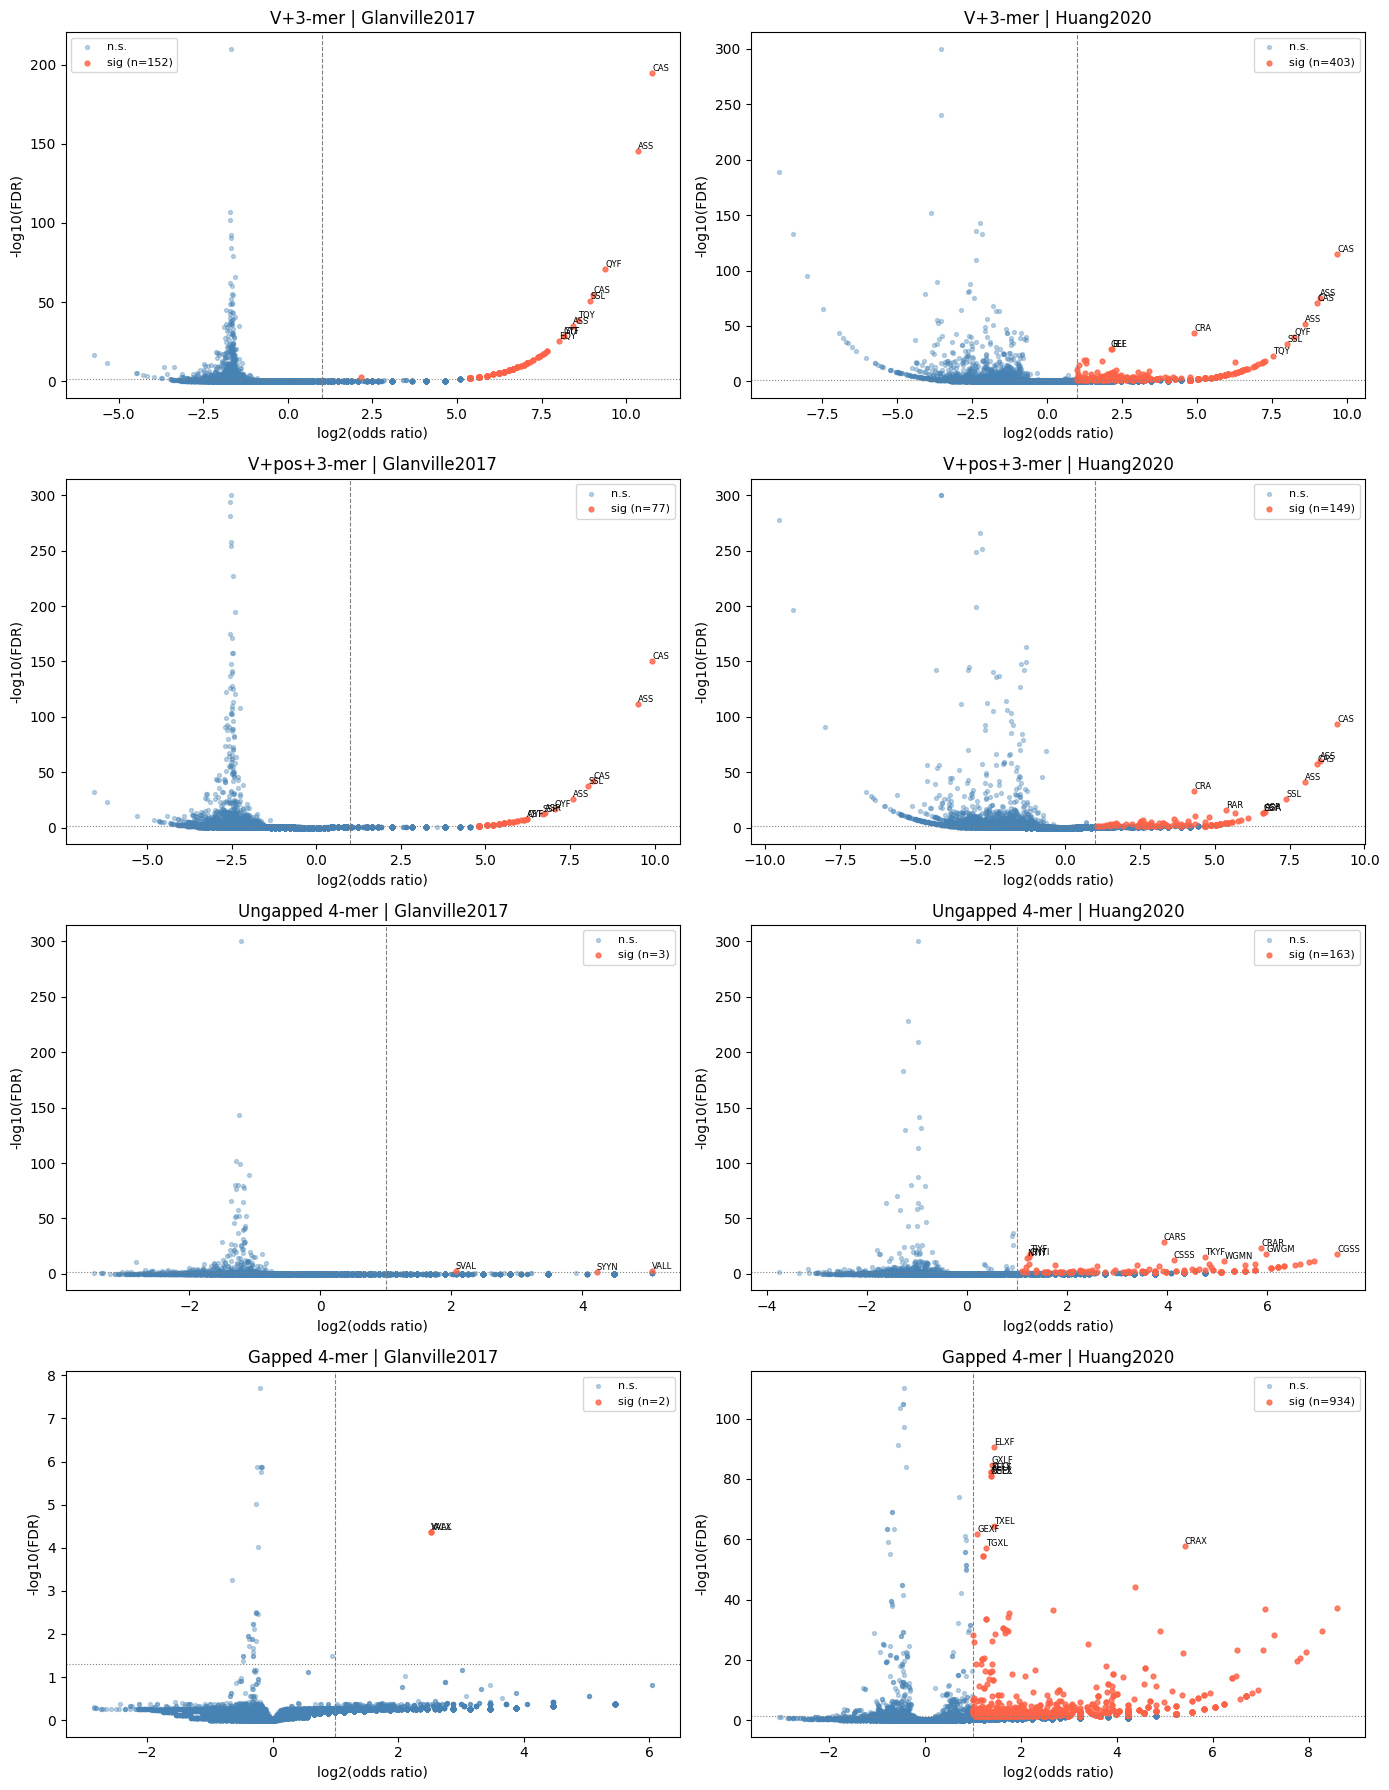

In [8]:
studies = sorted(next(iter(study_results.values())).keys())
n_studies = len(studies)

fig, axes = plt.subplots(
    nrows=len(FAMILIES),
    ncols=n_studies,
    figsize=(7 * n_studies, 4.5 * len(FAMILIES)),
    squeeze=False,
)

for row_i, family in enumerate(FAMILIES):
    for col_i, study in enumerate(studies):
        ax = axes[row_i, col_i]
        comp = study_results[family][study]['comparison'].copy()
        sig = study_results[family][study]['sig_mask']
        comp['log2or'] = np.log2(comp['odds_ratio'].clip(lower=1e-6))
        comp['neglog10p'] = -np.log10(comp['p_val_adj'].clip(lower=1e-300))

        ax.scatter(
            comp.loc[~sig, 'log2or'],
            comp.loc[~sig, 'neglog10p'],
            s=8, alpha=0.35, color='steelblue', label='n.s.'
        )
        ax.scatter(
            comp.loc[sig, 'log2or'],
            comp.loc[sig, 'neglog10p'],
            s=12, alpha=0.8, color='tomato', label=f'sig (n={int(sig.sum())})'
        )

        top = comp[sig].nlargest(TOP_LABELS, 'neglog10p')
        for _, row in top.iterrows():
            token_label = row.name.split('::', 3)[-1] if '::' in row.name else row.name
            ax.annotate(token_label, xy=(row['log2or'], row['neglog10p']), fontsize=6, ha='left', va='bottom')

        ax.axvline(np.log2(SIG_ODDS), color='grey', linestyle='--', linewidth=0.8)
        ax.axhline(-np.log10(SIG_FDR), color='grey', linestyle=':', linewidth=0.8)
        ax.set_xlabel('log2(odds ratio)')
        ax.set_ylabel('-log10(FDR)')
        ax.set_title(f'{FAMILY_LABELS[family]} | {study}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Build Bipartite Graphs and Clusters

Each family is analysed separately. Graphs include only enriched tokens, and clonotype node size scales with `log2(duplicate_count + 1)` after raw rows are collapsed to unique clonotypes.

In [9]:
def _build_study_graph(
    study_df: pd.DataFrame,
    sample_art: GliphTokenArtifacts,
    enriched_tokens: set[str],
) -> ig.Graph:
    edges = []
    token_nodes = sorted(enriched_tokens)
    clone_nodes = sorted({
        clone_id
        for token in enriched_tokens
        for clone_id in sample_art.token_to_clone.get(token, set())
    })
    all_nodes = token_nodes + clone_nodes
    node_idx = {name: i for i, name in enumerate(all_nodes)}

    for token in enriched_tokens:
        for clone_id in sample_art.token_to_clone.get(token, set()):
            edges.append((node_idx[token], node_idx[clone_id]))

    graph = ig.Graph(n=len(all_nodes), directed=False)
    graph.vs['name'] = all_nodes
    graph.vs['is_token'] = [True] * len(token_nodes) + [False] * len(clone_nodes)
    graph.add_edges(edges)

    clone_dup = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    token_degree = {token: len(sample_art.token_to_clone.get(token, set())) for token in token_nodes}
    graph.vs['color'] = ['tomato' if v['is_token'] else 'steelblue' for v in graph.vs]
    graph.vs['size'] = [
        7.0 + np.log2(token_degree.get(v['name'], 1) + 1.0) if v['is_token']
        else 2.0 + 2.0 * np.log2(clone_dup.get(v['name'], 1.0) + 1.0)
        for v in graph.vs
    ]
    return graph


def _plot_study_graph(
    graph: ig.Graph,
    title: str,
    max_nodes: int = MAX_GRAPH_NODES,
) -> None:
    if graph.vcount() == 0:
        print(f'{title}: no nodes to plot')
        return
    if graph.vcount() > max_nodes:
        print(f'{title}: {graph.vcount()} nodes - subsampling to {max_nodes}')
        keep = sorted(range(graph.vcount()), key=lambda i: -graph.degree(i))[:max_nodes]
        graph = graph.induced_subgraph(keep)

    layout = graph.layout('fr')
    fig, ax = plt.subplots(figsize=(10, 8))
    ig.plot(
        graph,
        layout=layout,
        target=ax,
        vertex_size=graph.vs['size'],
        vertex_color=graph.vs['color'],
        edge_width=0.4,
        edge_color='#cccccc',
        vertex_label=None,
    )
    ax.set_title(title)
    patches = [
        mpatches.Patch(color='tomato', label='enriched token'),
        mpatches.Patch(color='steelblue', label='clonotype (size ~ log2 duplicate_count)'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()



=== V+3-mer | Glanville2017 ===
Enriched tokens used in graph: 152
V+3-mer | Glanville2017 bipartite graph: 438 nodes - subsampling to 350


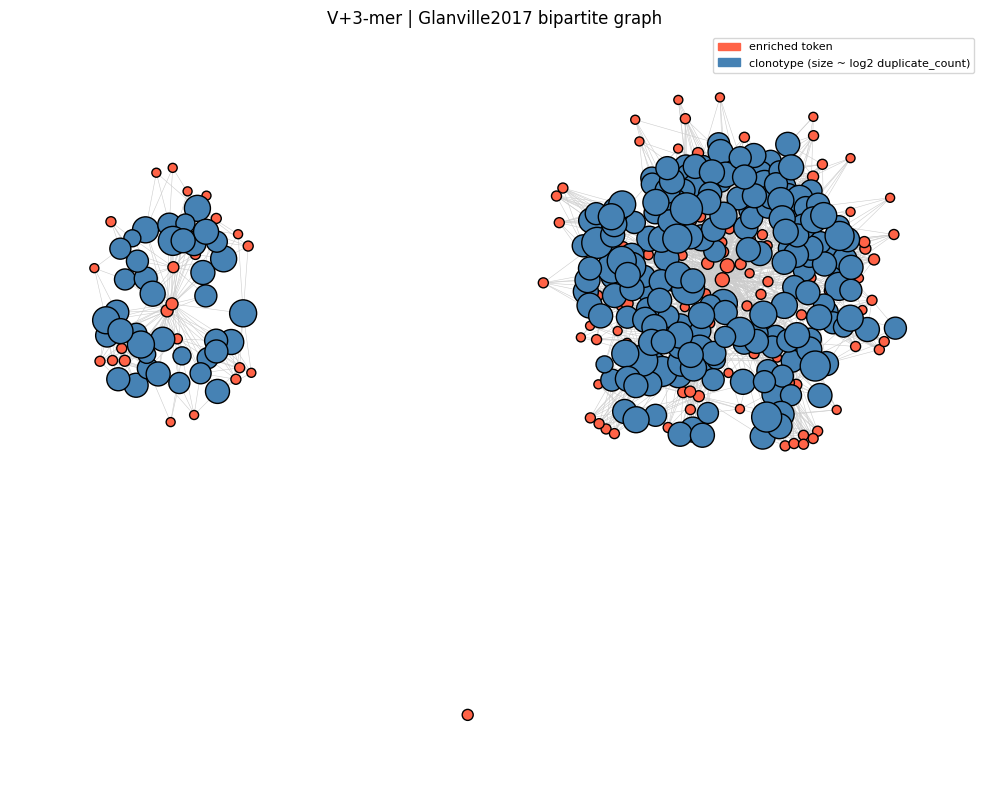


=== V+3-mer | Huang2020 ===
Enriched tokens used in graph: 403
V+3-mer | Huang2020 bipartite graph: 2799 nodes - subsampling to 350


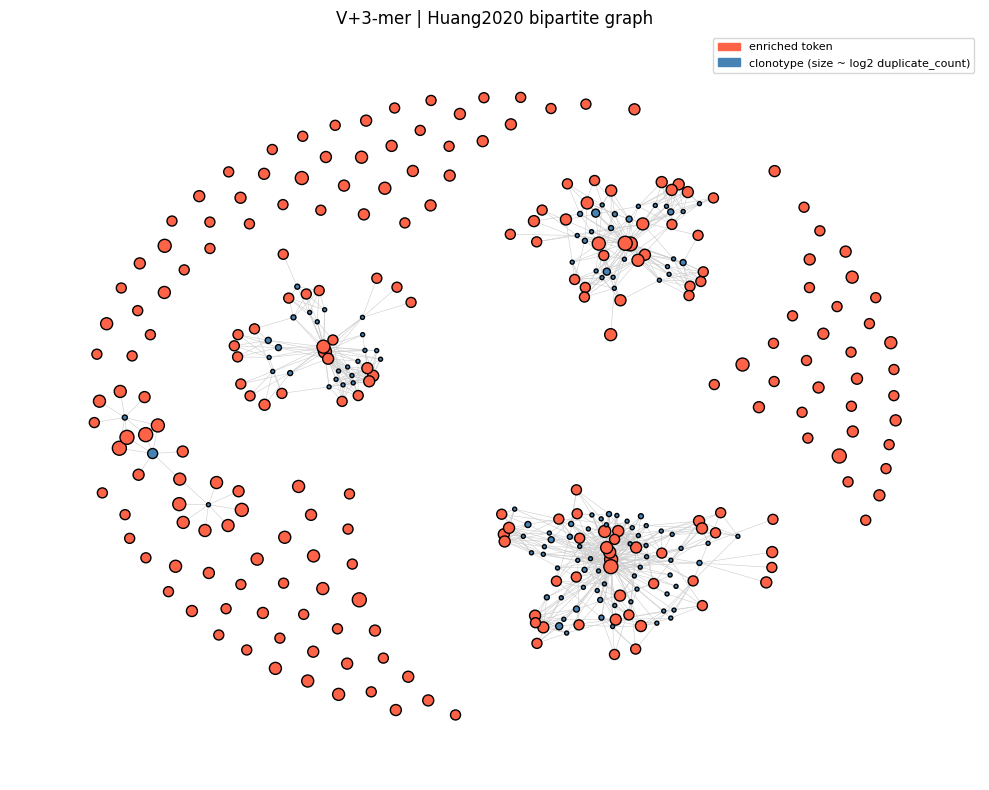


=== V+pos+3-mer | Glanville2017 ===
Enriched tokens used in graph: 77
V+pos+3-mer | Glanville2017 bipartite graph: 351 nodes - subsampling to 350


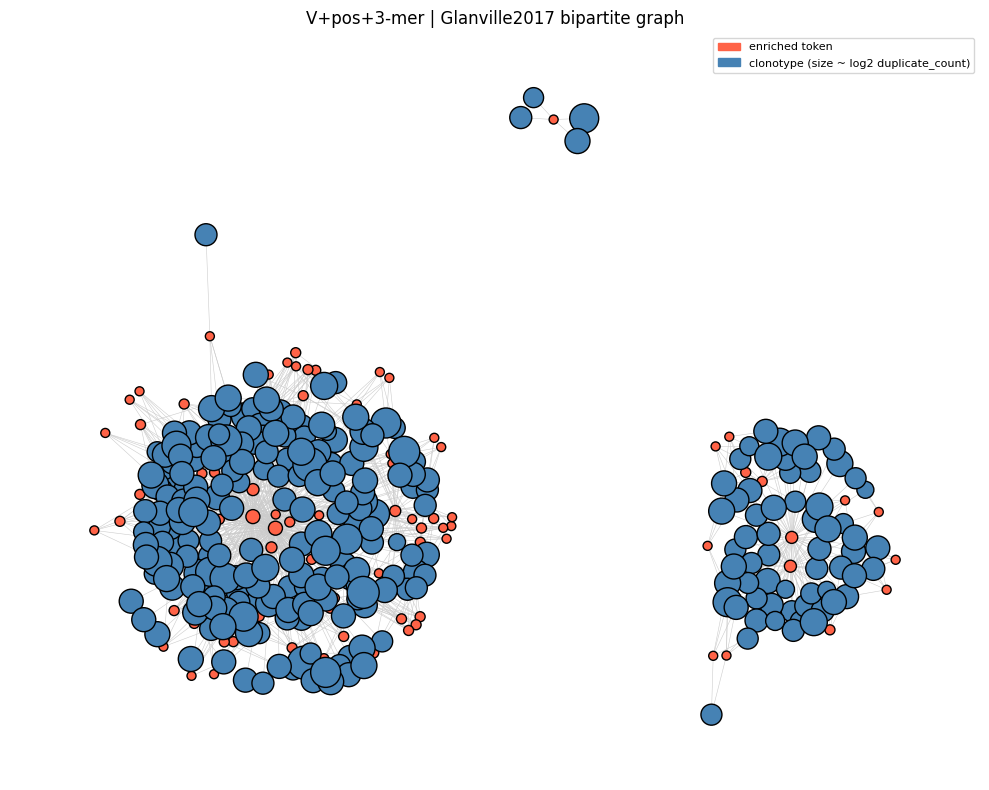


=== V+pos+3-mer | Huang2020 ===
Enriched tokens used in graph: 149
V+pos+3-mer | Huang2020 bipartite graph: 1158 nodes - subsampling to 350


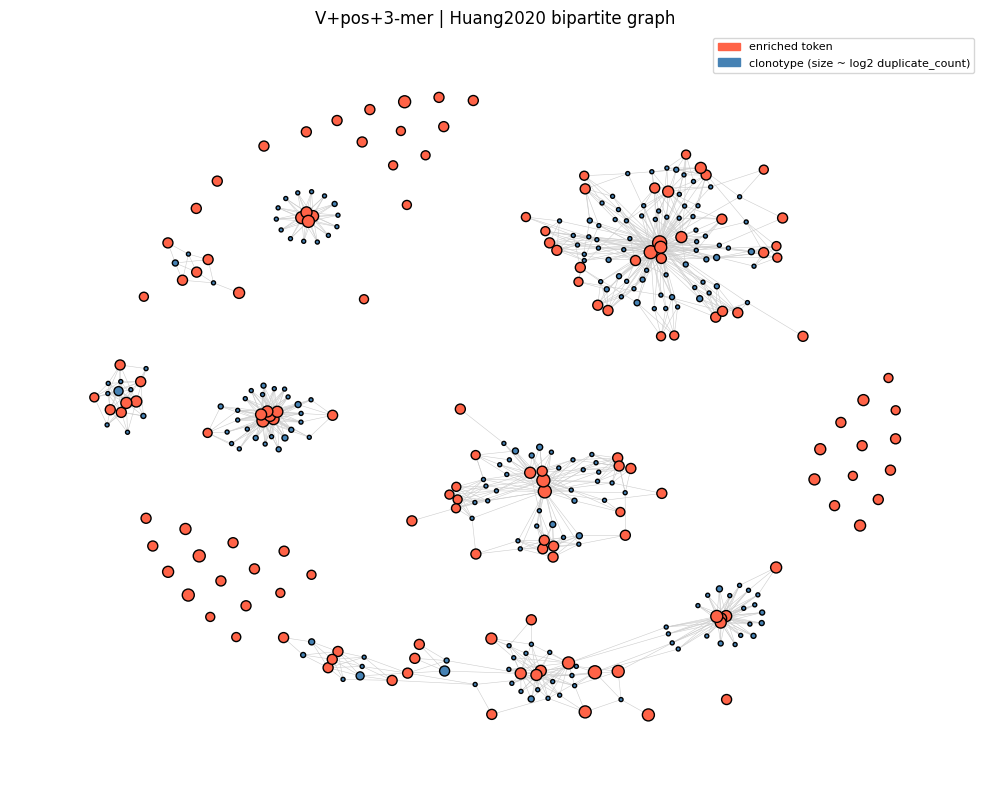


=== Ungapped 4-mer | Glanville2017 ===
Enriched tokens used in graph: 3


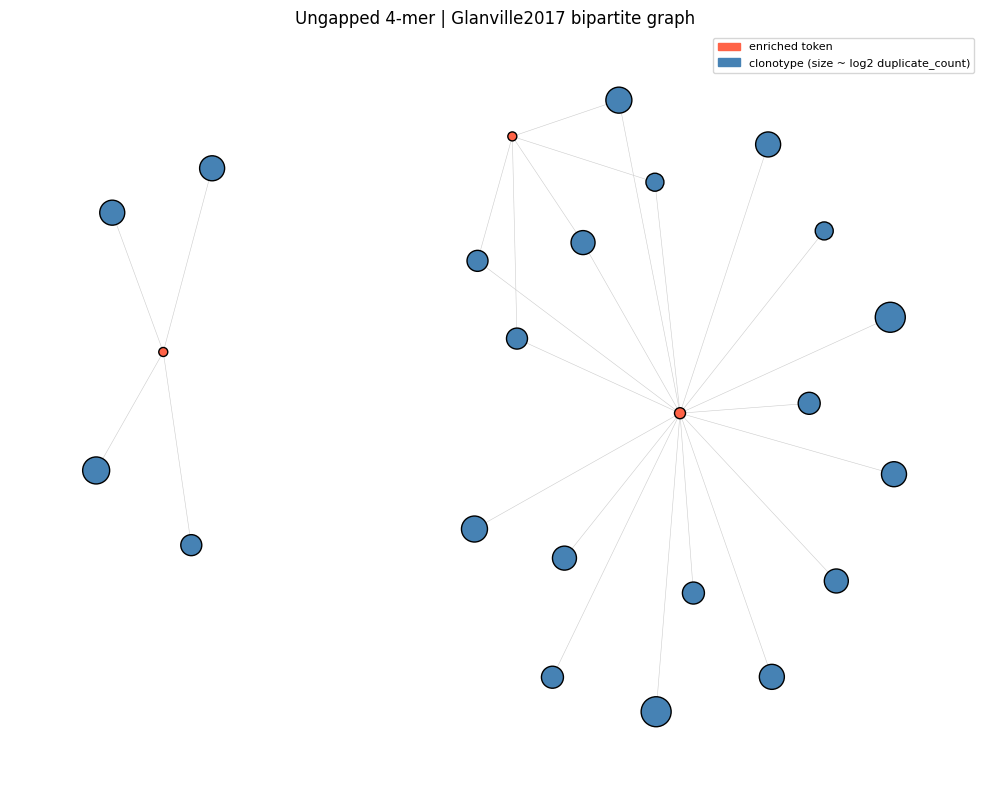


=== Ungapped 4-mer | Huang2020 ===
Enriched tokens used in graph: 163
Ungapped 4-mer | Huang2020 bipartite graph: 1607 nodes - subsampling to 350


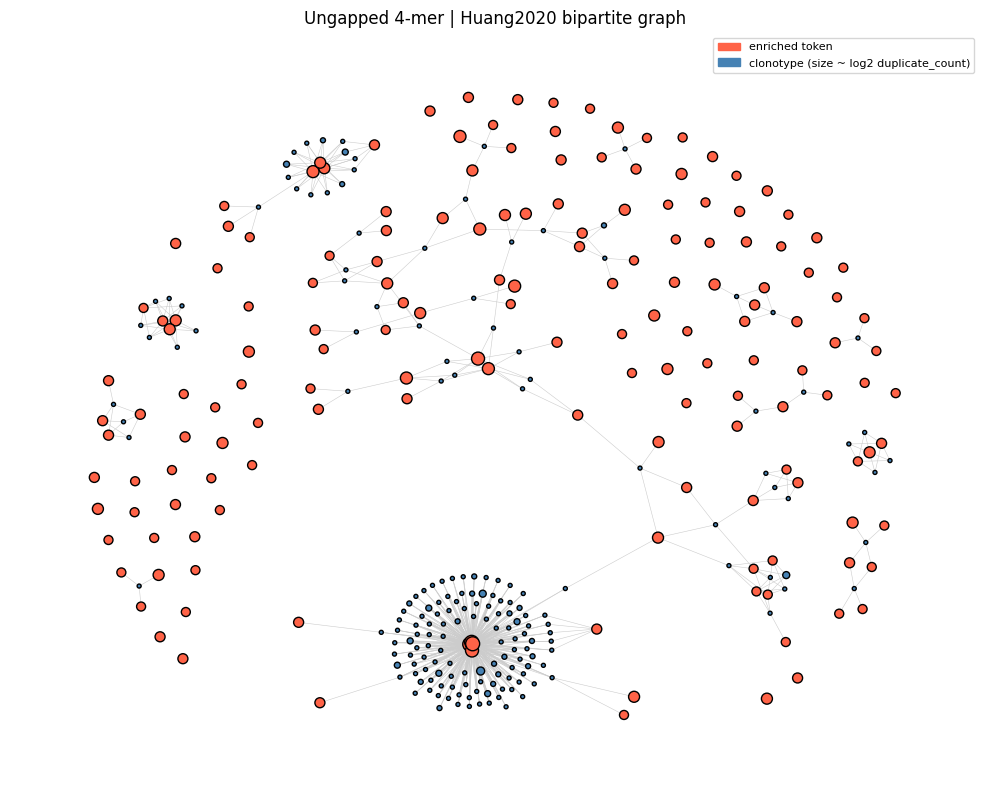


=== Gapped 4-mer | Glanville2017 ===
Enriched tokens used in graph: 2


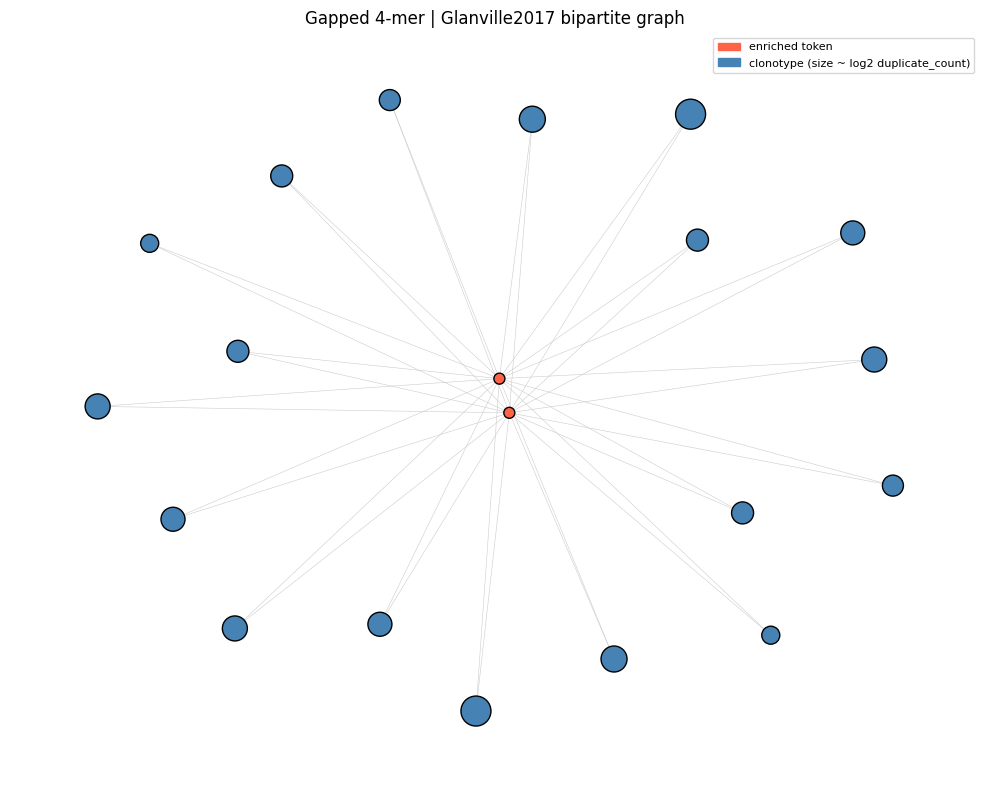


=== Gapped 4-mer | Huang2020 ===
Enriched tokens used in graph: 934
Gapped 4-mer | Huang2020 bipartite graph: 5983 nodes - subsampling to 350


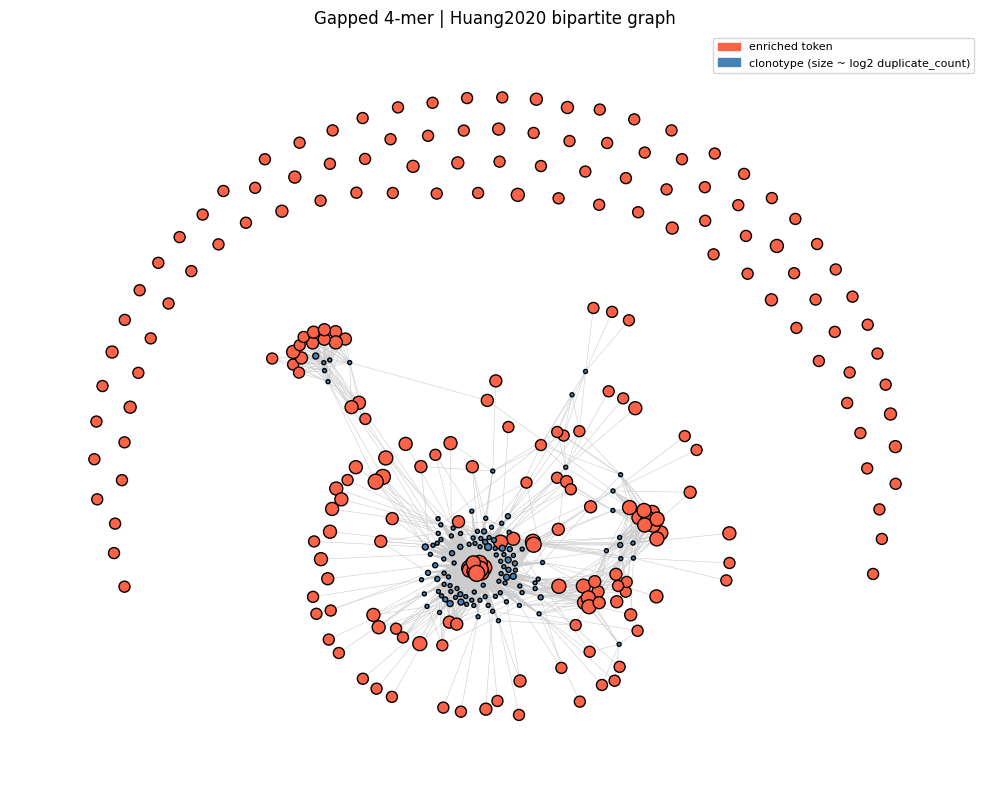

In [10]:
for family in FAMILIES:
    for study in sorted(study_results[family].keys()):
        payload = study_results[family][study]
        enriched_tokens = payload['enriched_tokens']
        print(f'\n=== {FAMILY_LABELS[family]} | {study} ===')
        print(f'Enriched tokens used in graph: {len(enriched_tokens)}')
        graph = _build_study_graph(payload['study_df'], payload['study_art'], enriched_tokens)
        _plot_study_graph(graph, title=f'{FAMILY_LABELS[family]} | {study} bipartite graph')


In [11]:
def _canonical_study_name(study_name: str) -> str | None:
    s = str(study_name).lower()
    for canon, keyword in STUDY_KEYWORDS.items():
        if keyword in s:
            return canon
    return None


def _purity_score(y_true: pd.Series, y_pred: pd.Series) -> float:
    tab = pd.crosstab(y_pred, y_true)
    if tab.empty:
        return float('nan')
    return float(tab.max(axis=1).sum() / tab.to_numpy().sum())


def _cluster_from_artifacts(
    study_df: pd.DataFrame,
    sample_art: GliphTokenArtifacts,
    enriched_tokens: set[str],
    method: str,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
) -> tuple[dict[str, int], dict[str, int]]:
    clone_ids_all = study_df['row_id'].astype(str).tolist()
    clone_set_all = set(clone_ids_all)

    token_to_clones = {}
    for token in enriched_tokens:
        filtered = sorted(c for c in sample_art.token_to_clone.get(token, set()) if c in clone_set_all)
        if filtered:
            token_to_clones[token] = filtered

    labels_all = {cid: -1 for cid in clone_ids_all}
    if not token_to_clones:
        return labels_all, {'n_clusters': 0, 'n_clustered': 0, 'n_total': len(clone_ids_all)}

    token_nodes = sorted(token_to_clones.keys())
    active_clone_ids = sorted({cid for ids in token_to_clones.values() for cid in ids})
    token_idx = {t: i for i, t in enumerate(token_nodes)}
    clone_offset = len(token_nodes)
    clone_idx = {c: clone_offset + i for i, c in enumerate(active_clone_ids)}

    graph = ig.Graph(n=len(token_nodes) + len(active_clone_ids), directed=False)
    graph.add_edges(
        (token_idx[token], clone_idx[cid])
        for token, ids in token_to_clones.items()
        for cid in ids
    )

    if method == 'components':
        membership = np.full(graph.vcount(), -1, dtype=int)
        for comp_id, vertices in enumerate(graph.components()):
            for vertex in vertices:
                membership[vertex] = comp_id
    elif method == 'leiden':
        membership = np.array(
            graph.community_leiden(objective_function='modularity', n_iterations=5).membership,
            dtype=int,
        )
    else:
        raise ValueError(f'Unknown method: {method}')

    clone_labels = np.array([membership[clone_idx[cid]] for cid in active_clone_ids], dtype=int)
    keep_mask = np.zeros_like(clone_labels, dtype=bool)
    for label in np.unique(clone_labels):
        if (clone_labels == label).sum() >= min_cluster_size:
            keep_mask |= (clone_labels == label)
    clone_labels = np.where(keep_mask, clone_labels, -1)

    for cid, label in zip(active_clone_ids, clone_labels):
        labels_all[cid] = int(label)

    stats = {
        'n_clusters': int(len(set(clone_labels[clone_labels >= 0]))),
        'n_clustered': int((clone_labels >= 0).sum()),
        'n_total': len(clone_ids_all),
    }
    return labels_all, stats


def _make_cluster_table(
    study_df: pd.DataFrame,
    sample_art: GliphTokenArtifacts,
    labels_map: dict[str, int],
    top_n: int = 15,
) -> pd.DataFrame:
    rows = []
    sdf_map = study_df.set_index('row_id')
    labels = sorted({label for label in labels_map.values() if label >= 0})
    for label in labels:
        member_ids = [rid for rid, value in labels_map.items() if value == label]
        member_rows = sdf_map.loc[sdf_map.index.intersection(member_ids)]
        tokens = set()
        for rid in member_ids:
            tokens.update(sample_art.clone_to_tokens.get(rid, set()))
        rows.append({
            'cluster': label,
            'size': len(member_ids),
            'mean_duplicate_count': float(member_rows['duplicate_count'].mean()) if len(member_rows) else np.nan,
            'top_tokens': ', '.join(sorted(tokens)[:5]),
            'sequences': ' | '.join(member_rows['junction_aa'].astype(str).tolist()[:5]),
        })
    if not rows:
        return pd.DataFrame(columns=['cluster', 'size', 'mean_duplicate_count', 'top_tokens', 'sequences'])
    return pd.DataFrame(rows).sort_values('size', ascending=False).head(top_n)


def _concordance_row(
    study_df: pd.DataFrame,
    labels_map: dict[str, int],
    target_col: str,
    target_name: str,
    canonical_study: str | None,
    family: str,
    method: str,
) -> dict[str, object]:
    tmp = study_df[['row_id', target_col]].copy()
    tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
    tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()
    n_target_total = len(tmp)
    if n_target_total == 0:
        return {
            'canonical_study': canonical_study,
            'reference_id': str(study_df['reference_id'].iloc[0]),
            'family': family,
            'method': method,
            'config': f'{family}+{method}',
            'target_name': target_name,
            'n_total': len(study_df),
            'n_target_total': 0,
            'n_eval': 0,
            'coverage': 0.0,
            'ami': np.nan,
            'nmi': np.nan,
            'ari': np.nan,
            'purity': np.nan,
        }

    tmp['pred_cluster'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
    coverage = float((tmp['pred_cluster'] >= 0).mean())
    eval_df = tmp[tmp['pred_cluster'] >= 0].copy()

    if len(eval_df) < 2 or eval_df['pred_cluster'].nunique() < 2 or eval_df['target'].nunique() < 2:
        ami = nmi = ari = purity = np.nan
    else:
        ami = adjusted_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        nmi = normalized_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        ari = adjusted_rand_score(eval_df['target'], eval_df['pred_cluster'])
        purity = _purity_score(eval_df['target'], eval_df['pred_cluster'])

    return {
        'canonical_study': canonical_study,
        'reference_id': str(study_df['reference_id'].iloc[0]),
        'family': family,
        'method': method,
        'config': f'{family}+{method}',
        'target_name': target_name,
        'n_total': len(study_df),
        'n_target_total': n_target_total,
        'n_eval': len(eval_df),
        'coverage': coverage,
        'ami': ami,
        'nmi': nmi,
        'ari': ari,
        'purity': purity,
    }


In [12]:
cluster_tables: dict[tuple[str, str, str], pd.DataFrame] = {}
cluster_labels: dict[tuple[str, str, str], dict[str, int]] = {}
cluster_stats_rows: list[dict[str, object]] = []
concordance_rows: list[dict[str, object]] = []

for family in FAMILIES:
    for study in sorted(study_results[family].keys()):
        payload = study_results[family][study]
        sample_art = payload['study_art']
        study_df = payload['study_df']
        enriched_tokens = payload['enriched_tokens']
        canonical = _canonical_study_name(study)

        for method in CLUSTER_METHODS:
            labels_map, stats = _cluster_from_artifacts(
                study_df=study_df,
                sample_art=sample_art,
                enriched_tokens=enriched_tokens,
                method=method,
                min_cluster_size=MIN_CLUSTER_SIZE,
            )
            cluster_labels[(family, method, study)] = labels_map
            cluster_tables[(family, method, study)] = _make_cluster_table(study_df, sample_art, labels_map)

            cluster_stats_rows.append({
                'canonical_study': canonical,
                'reference_id': study,
                'family': family,
                'method': method,
                'config': f'{family}+{method}',
                'n_enriched_tokens': len(enriched_tokens),
                'n_clusters': stats['n_clusters'],
                'n_clustered': stats['n_clustered'],
                'n_total': stats['n_total'],
                'clustered_frac': stats['n_clustered'] / stats['n_total'] if stats['n_total'] else np.nan,
            })

            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='gliph_cluster_id',
                target_name='gliph_cluster_id',
                canonical_study=canonical,
                family=family,
                method=method,
            ))
            if canonical == 'Glanville2017':
                concordance_rows.append(_concordance_row(
                    study_df=study_df,
                    labels_map=labels_map,
                    target_col='stimulus',
                    target_name='stimulus',
                    canonical_study=canonical,
                    family=family,
                    method=method,
                ))
            elif canonical == 'Huang2020':
                concordance_rows.append(_concordance_row(
                    study_df=study_df,
                    labels_map=labels_map,
                    target_col='epitope',
                    target_name='epitope',
                    canonical_study=canonical,
                    family=family,
                    method=method,
                ))

cluster_stats_df = pd.DataFrame(cluster_stats_rows).sort_values(
    ['canonical_study', 'reference_id', 'family', 'method']
).reset_index(drop=True)
concordance_df = pd.DataFrame(concordance_rows).sort_values(
    ['canonical_study', 'reference_id', 'target_name', 'family', 'method']
).reset_index(drop=True)

print('Cluster statistics table:')
display(cluster_stats_df)

print('Concordance table:')
display(concordance_df)


Cluster statistics table:


,canonical_study,reference_id,family,method,config,n_enriched_tokens,n_clusters,n_clustered,n_total,clustered_frac
0,Glanville2017,Glanville2017,g4,components,g4+components,2,1,18,3928,0.004582
1,Glanville2017,Glanville2017,g4,leiden,g4+leiden,2,1,18,3928,0.004582
2,Glanville2017,Glanville2017,u4,components,u4+components,3,2,21,3928,0.005346
3,Glanville2017,Glanville2017,u4,leiden,u4+leiden,3,3,21,3928,0.005346
4,Glanville2017,Glanville2017,v3,components,v3+components,152,3,286,3928,0.072811
5,Glanville2017,Glanville2017,v3,leiden,v3+leiden,152,12,286,3928,0.072811
6,Glanville2017,Glanville2017,vpos3,components,vpos3+components,77,3,274,3928,0.069756
7,Glanville2017,Glanville2017,vpos3,leiden,vpos3+leiden,77,11,274,3928,0.069756
8,Huang2020,Huang2020,g4,components,g4+components,934,2,5049,9934,0.508254
9,Huang2020,Huang2020,g4,leiden,g4+leiden,934,28,5047,9934,0.508053


Concordance table:


,canonical_study,reference_id,family,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,g4,components,g4+components,gliph_cluster_id,3928,1287,15,0.011655,NaN,NaN,NaN,NaN
1,Glanville2017,Glanville2017,g4,leiden,g4+leiden,gliph_cluster_id,3928,1287,15,0.011655,NaN,NaN,NaN,NaN
2,Glanville2017,Glanville2017,u4,components,u4+components,gliph_cluster_id,3928,1287,18,0.013986,0.881014,0.894674,0.968921,0.944444
3,Glanville2017,Glanville2017,u4,leiden,u4+leiden,gliph_cluster_id,3928,1287,18,0.013986,0.527662,0.604589,0.434335,0.944444
4,Glanville2017,Glanville2017,v3,components,v3+components,gliph_cluster_id,3928,1287,108,0.083916,0.088975,0.337994,0.039575,0.194444
5,Glanville2017,Glanville2017,v3,leiden,v3+leiden,gliph_cluster_id,3928,1287,108,0.083916,0.251183,0.684248,0.245797,0.287037
6,Glanville2017,Glanville2017,vpos3,components,vpos3+components,gliph_cluster_id,3928,1287,96,0.074592,0.026924,0.260569,0.003571,0.083333
7,Glanville2017,Glanville2017,vpos3,leiden,vpos3+leiden,gliph_cluster_id,3928,1287,96,0.074592,0.052799,0.627270,0.016803,0.166667
8,Glanville2017,Glanville2017,g4,components,g4+components,stimulus,3928,3928,18,0.004582,NaN,NaN,NaN,NaN
9,Glanville2017,Glanville2017,g4,leiden,g4+leiden,stimulus,3928,3928,18,0.004582,NaN,NaN,NaN,NaN



=== Gapped 4-mer + components | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_tokens,sequences
0,0,18,4248.055556,"g4::AEXF, g4::AEYX, g4::AGAX, g4::AGDX, g4::AGGX",CASSVALMGGELFF | CSVALSGQGKYF | CASSVALYANEQFF...



=== Gapped 4-mer + components | Huang2020 ===


,cluster,size,mean_duplicate_count,top_tokens,sequences
0,0,5046,1.404677,"g4::AAAX, g4::AADX, g4::AAEX, g4::AAFX, g4::AAGX",CASRPGLWGEQFF | CASSDPKGPYRSYNEQFF | CASSFEKGI...
1,1,3,1.000000,"g4::ASRX, g4::ASSX, g4::ASXA, g4::ASXS, g4::AWQX",CASRSWQLSYNEQFF | CASSAWQLAYNEQFF | CASSSWQLSY...



=== Gapped 4-mer + leiden | Glanville2017 ===


...


=== V+pos+3-mer + leiden | Huang2020 ===


,cluster,size,mean_duplicate_count,top_tokens,sequences
0,0,154,1.298701,"vpos3::TRBV12-3::0::CAC, vpos3::TRBV12-3::0::C...",CASSPLVAGSSYEQYF | CASTHGLAVYNEQFF | CASVGHTEA...
23,23,96,1.135417,"vpos3::TRBV7-2::0::CAG, vpos3::TRBV7-2::0::CAP...",CASGPGLAGVLGANVLTF | CASSLMRGGGTGELFF | CDSSFG...
21,21,95,1.326316,"vpos3::TRBV6-2::0::CAS, vpos3::TRBV6-2::0::CDS...",CASRSRGGRTYNEQFF | CASTLTGHTGELFF | CASRSGLMNT...
19,19,87,1.379310,"vpos3::TRBV5-4::0::CAC, vpos3::TRBV5-4::0::CAD...",CASNWGGRQETQYF | CASSQTGNSYEQYF | CASSSGHLQETQ...
3,3,79,1.227848,"vpos3::TRBV20-1::0::CRA, vpos3::TRBV20-1::0::C...",CRAGQEPGGGGEKLFF | CRAGQGADTEAFF | CRARERARHEQ...
2,2,73,3.479452,"vpos3::TRBV20-1::0::CGA, vpos3::TRBV20-1::0::C...",CSAYSPGLAGFQETQYF | CSAHSPGPAGHSYNEQFF | CSALA...
1,1,70,1.557143,"vpos3::TRBV20-1::0::CCA, vpos3::TRBV20-1::0::C...",CSAQKIGGGNYGYTF | CGARGRVEYEEDF | CSARDGGGGTDT...
5,5,53,1.301887,"vpos3::TRBV20-1::0::CGG, vpos3::TRBV20-1::0::C...",CSARASGSWNTGELFF | CSASRAASGRIGELFF | CSARDWAS...
4,4,40,1.150000,"vpos3::TRBV20-1::0::CSA, vpos3::TRBV20-1::10::...",CSAGTGGISGELFF | CSALGILPTGELFF | CSARRATNTGEL...
10,10,38,1.552632,"vpos3::TRBV29-1::0::CIV, vpos3::TRBV29-1::0::C...",CSAGPGWGMNTEAFF | CSVGTSGGQNTEELFF | CSAKAGWGM...


,canonical_study,reference_id,family,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,g4,components,g4+components,gliph_cluster_id,3928,1287,15,0.011655,NaN,NaN,NaN,NaN
1,Glanville2017,Glanville2017,g4,leiden,g4+leiden,gliph_cluster_id,3928,1287,15,0.011655,NaN,NaN,NaN,NaN
2,Glanville2017,Glanville2017,u4,components,u4+components,gliph_cluster_id,3928,1287,18,0.013986,0.881014,0.894674,0.968921,0.944444
3,Glanville2017,Glanville2017,u4,leiden,u4+leiden,gliph_cluster_id,3928,1287,18,0.013986,0.527662,0.604589,0.434335,0.944444
4,Glanville2017,Glanville2017,v3,components,v3+components,gliph_cluster_id,3928,1287,108,0.083916,0.088975,0.337994,0.039575,0.194444
5,Glanville2017,Glanville2017,v3,leiden,v3+leiden,gliph_cluster_id,3928,1287,108,0.083916,0.251183,0.684248,0.245797,0.287037
6,Glanville2017,Glanville2017,vpos3,components,vpos3+components,gliph_cluster_id,3928,1287,96,0.074592,0.026924,0.260569,0.003571,0.083333
7,Glanville2017,Glanville2017,vpos3,leiden,vpos3+leiden,gliph_cluster_id,3928,1287,96,0.074592,0.052799,0.627270,0.016803,0.166667
8,Glanville2017,Glanville2017,g4,components,g4+components,stimulus,3928,3928,18,0.004582,NaN,NaN,NaN,NaN
9,Glanville2017,Glanville2017,g4,leiden,g4+leiden,stimulus,3928,3928,18,0.004582,NaN,NaN,NaN,NaN


Target-label availability:


,study,n_rows,n_with_gliph_cluster_id,n_with_stimulus,n_with_epitope
0,Glanville2017,3928,1287,3928,0
1,Huang2020,9934,4493,9934,0


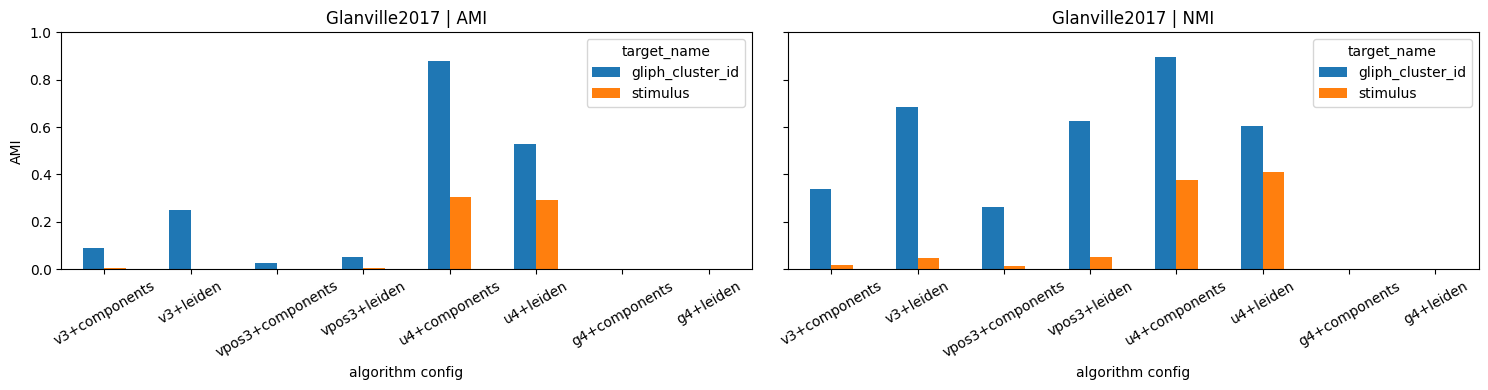

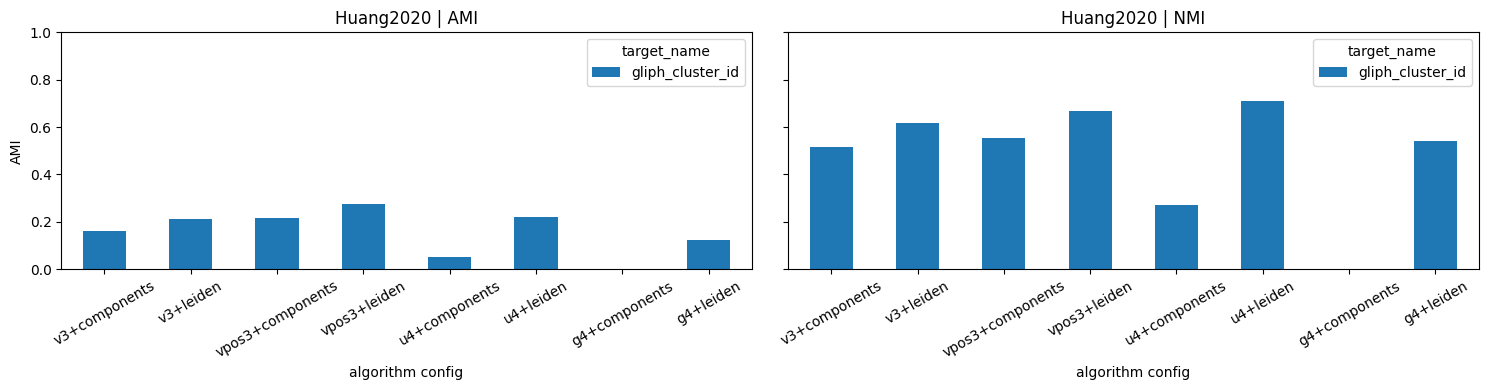

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique clonotypes by `(reference_id, junction_aa, v_gene, j_gene)` before token counting.
- Token extraction uses `clonotype` counts, `4` threads, and `MIN_TOKEN_CLONOTYPES >= 2` before clustering.
- Evaluated token families: `v3`, `vpos3`, `u4`, `g4` with both connected components and Leiden clustering.
- Bipartite graphs now scale clonotype nodes by `log2(duplicate_count + 1)` and use enriched tokens only.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Benchmark-guided interpretation: `u4` strongly reduces the number of enriched tokens for `Glanville2017`, while `vpos3` improves `Huang2020` concordance to `gliph_cluster_id` relative to the old gapped-4 baseline.
- Glanville2017 vs gliph_cluster_id: best `u4+components` with AMI=0.881, NMI=0.895, ARI=0.969, purity=0.944, coverage=1.4%.
- Glanville2017 vs stimulus: best `u4+components` with AMI=0.303, NMI=0.378, ARI=0.354, purity=0.667, coverage=0.5%.
- Huang2020 vs gliph_cluster_id: best `vpos3+leiden` with AMI=0.275, NMI=0.667, ARI=0.095, purity=0.201, coverage=13.2%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.

In [15]:
# Top cluster previews per (family, method, study)
for key in sorted(cluster_tables.keys()):
    family, method, study = key
    tab = cluster_tables[key]
    print(f'\n=== {FAMILY_LABELS[family]} + {method} | {study} ===')
    if tab.empty:
        print('  (no clusters)')
    else:
        display(tab.head(10))

focus_studies = {'Glanville2017', 'Huang2020'}
focus_conc = concordance_df[concordance_df['canonical_study'].isin(focus_studies)].copy()
display(focus_conc)

availability_rows = []
for study_name in sorted(focus_studies):
    sdf = df[df['reference_id'].str.contains(STUDY_KEYWORDS[study_name], case=False, na=False)].copy()
    if sdf.empty:
        continue
    availability_rows.append({
        'study': study_name,
        'n_rows': len(sdf),
        'n_with_gliph_cluster_id': int((sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_stimulus': int((sdf['stimulus'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_epitope': int((sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
    })
availability_df = pd.DataFrame(availability_rows)
print('Target-label availability:')
display(availability_df)

config_order = [f'{family}+{method}' for family in FAMILIES for method in CLUSTER_METHODS]
for study_name in sorted(focus_conc['canonical_study'].dropna().unique()):
    study_df_plot = focus_conc[focus_conc['canonical_study'] == study_name].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
    for ax, metric in zip(axes, ['ami', 'nmi']):
        piv = study_df_plot.pivot_table(
            index='config', columns='target_name', values=metric, aggfunc='mean'
        ).reindex(config_order)
        piv.plot(kind='bar', ax=ax)
        ax.set_title(f'{study_name} | {metric.upper()}')
        ax.set_xlabel('algorithm config')
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

requested_targets = {
    'Glanville2017': ['gliph_cluster_id', 'stimulus'],
    'Huang2020': ['gliph_cluster_id', 'epitope'],
}
best_rows = []
for study_name, targets in requested_targets.items():
    for target_name in targets:
        sub_all = focus_conc[
            (focus_conc['canonical_study'] == study_name)
            & (focus_conc['target_name'] == target_name)
        ].copy()
        if sub_all.empty:
            best_rows.append(f'- {study_name} vs {target_name}: no rows available in concordance table.')
            continue
        if int(sub_all['n_target_total'].max()) == 0:
            best_rows.append(f'- {study_name} vs {target_name}: no non-empty labels in this dataset snapshot.')
            continue
        sub = sub_all.dropna(subset=['ami']).copy()
        if sub.empty:
            best_rows.append(
                f"- {study_name} vs {target_name}: labels exist but no evaluable configuration (needs >=2 predicted clusters and >=2 target classes)."
            )
            continue
        row = sub.sort_values(['ami', 'n_eval'], ascending=[False, False]).iloc[0]
        best_rows.append(
            f"- {study_name} vs {target_name}: best `{row['config']}` with AMI={row['ami']:.3f}, NMI={row['nmi']:.3f}, ARI={row['ari']:.3f}, purity={row['purity']:.3f}, coverage={row['coverage']:.1%}."
        )

summary_lines = [
    '## End-of-Notebook Summary',
    '',
    '- GLIPH input was deduplicated to unique clonotypes by `(reference_id, junction_aa, v_gene, j_gene)` before token counting.',
    f'- Token extraction uses `{COUNT_MODE}` counts, `{TOKEN_THREADS}` threads, and `MIN_TOKEN_CLONOTYPES >= {MIN_TOKEN_CLONOTYPES}` before clustering.',
    '- Evaluated token families: `v3`, `vpos3`, `u4`, `g4` with both connected components and Leiden clustering.',
    '- Bipartite graphs now scale clonotype nodes by `log2(duplicate_count + 1)` and use enriched tokens only.',
    '- Concordance targets:',
    '  - `Glanville2017`: `stimulus` and `gliph_cluster_id`',
    '  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)',
    '- Benchmark-guided interpretation: `u4` strongly reduces the number of enriched tokens for `Glanville2017`, while `vpos3` improves `Huang2020` concordance to `gliph_cluster_id` relative to the old gapped-4 baseline.',
 ]
summary_lines.extend(best_rows)
display(Markdown('\n'.join(summary_lines)))

## Brief Conclusions and Context

- This pipeline reproduces a core GLIPH-like idea: motif/token enrichment against controls, followed by motif-linked clustering.
- Compared to **Huang et al., 2020 (Nat Biotech)** (https://www.nature.com/articles/s41587-020-0505-4), this notebook is a lighter implementation and does not include all GLIPH2 constraints (e.g., global/local motif scoring calibration and full HLA-aware priors).
- Relative to **Glanville et al., 2017 (Nature)** (https://pubmed.ncbi.nlm.nih.gov/28636589/), the bipartite token graph here captures motif-sharing structure similarly, but exact cluster boundaries may differ because we use explicit Fisher enrichment + FDR thresholds and connected-component/community heuristics.
- Practical interpretation:
  - Higher Cramer's V / AMI / NMI and lower stimulated-unclustered fraction indicate better stimulus separation by token-defined clusters.
  - Silhouette can be conservative in sparse high-dimensional token spaces; use it together with chi2/Cramer's V and cluster composition tables.

A run-specific summary is generated in the final code cell as **End-of-Notebook Summary** after all computations complete.

In [16]:
# Repeat final summary at literal notebook end for convenience.
if 'summary_lines' in globals():
    display(Markdown('\n'.join(summary_lines)))
else:
    print('Run the previous analysis cell first to generate end-of-notebook summary.')

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique clonotypes by `(reference_id, junction_aa, v_gene, j_gene)` before token counting.
- Token extraction uses `clonotype` counts, `4` threads, and `MIN_TOKEN_CLONOTYPES >= 2` before clustering.
- Evaluated token families: `v3`, `vpos3`, `u4`, `g4` with both connected components and Leiden clustering.
- Bipartite graphs now scale clonotype nodes by `log2(duplicate_count + 1)` and use enriched tokens only.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Benchmark-guided interpretation: `u4` strongly reduces the number of enriched tokens for `Glanville2017`, while `vpos3` improves `Huang2020` concordance to `gliph_cluster_id` relative to the old gapped-4 baseline.
- Glanville2017 vs gliph_cluster_id: best `u4+components` with AMI=0.881, NMI=0.895, ARI=0.969, purity=0.944, coverage=1.4%.
- Glanville2017 vs stimulus: best `u4+components` with AMI=0.303, NMI=0.378, ARI=0.354, purity=0.667, coverage=0.5%.
- Huang2020 vs gliph_cluster_id: best `vpos3+leiden` with AMI=0.275, NMI=0.667, ARI=0.095, purity=0.201, coverage=13.2%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.